In [1]:
import json

from lora.preprocess_dataset import create_docred_hf_dataset
import os
from dotenv import load_dotenv

load_dotenv()
data_dir = os.getenv('LORA_TRAIN_DATA_DIR', '')

# 2. 替换为你即将用于 LoRA 训练的基座模型本地路径或 HuggingFace ID
model_path = os.getenv('LLM_MODEL_PAHT', '')  # 例如 '/path/to/your/llm'

# 3. 创建数据集
print("正在加载数据集...")
train_dataset = create_docred_hf_dataset(
    os.path.join(data_dir, 'train.json'),
    os.path.join(data_dir, 'relation_type.json')
)

val_dataset = create_docred_hf_dataset(
    os.path.join(data_dir, 'val.json'),
    os.path.join(data_dir, 'relation_type.json')
)


/home/lyq/anaconda3/envs/fact_verf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在加载数据集...


In [3]:
import numpy as np
from transformers import AutoTokenizer


def get_seq_len_counts(tokenizer_name_or_path, dataset):
    print(f"正在加载 Tokenizer: {tokenizer_name_or_path}...")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name_or_path, trust_remote_code=True)

    seq_lengths = []

    print("开始计算 Token 长度，这可能需要一点时间...")
    for example in dataset:
        messages = example["messages"]

        # 尝试使用模型自带的 Chat Template 进行拼接，这最符合实际训练的格式
        if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
            try:
                # tokenize=True 直接返回 token ID 列表
                token_ids = tokenizer.apply_chat_template(
                    messages,
                    tokenize=True,
                    add_generation_prompt=False
                )
                seq_lengths.append(len(token_ids.tokens()))
                continue
            except Exception:
                # 如果当前模型不支持 apply_chat_template，则降级处理
                pass

        # 降级处理：手动拼接 user 和 assistant 的文本
        full_text = ""
        for msg in messages:
            full_text += msg["content"] + "\n"

        tokens = tokenizer.encode(full_text, add_special_tokens=True)
        seq_lengths.append(len(tokens))

    # 转换为 numpy 数组进行百分位数统计
    lengths_array = np.array(seq_lengths)

    # 打印统计结果
    print("\n" + "=" * 50)
    print(f"数据集 Token 长度分布统计 (共 {len(lengths_array)} 条样本)")
    print("=" * 50)
    print(f"最短长度 (Min):      {np.min(lengths_array)}")
    print(f"最长长度 (Max):      {np.max(lengths_array)}")
    print(f"平均长度 (Mean):     {np.mean(lengths_array):.2f}")
    print(f"50% 分位数 (Median): {np.percentile(lengths_array, 50):.0f}")
    print(f"90% 分位数:          {np.percentile(lengths_array, 90):.0f}")
    print(f"95% 分位数:          {np.percentile(lengths_array, 95):.0f}")
    print(f"99% 分位数:          {np.percentile(lengths_array, 99):.0f}")
    print("=" * 50)
    return lengths_array

tokenizer_name_or_path = os.getenv('LLM_MODEL_PAHT', None)
train_seq_len_list, val_seq_len_list = get_seq_len_counts(tokenizer_name_or_path, train_dataset), get_seq_len_counts(tokenizer_name_or_path, val_dataset)

正在加载 Tokenizer: /home/lyq/Models/Qwen3.5-4B...
开始计算 Token 长度，这可能需要一点时间...

数据集 Token 长度分布统计 (共 1598 条样本)
最短长度 (Min):      248
最长长度 (Max):      1969
平均长度 (Mean):     640.26
50% 分位数 (Median): 608
90% 分位数:          908
95% 分位数:          1022
99% 分位数:          1325
正在加载 Tokenizer: /home/lyq/Models/Qwen3.5-4B...
开始计算 Token 长度，这可能需要一点时间...

数据集 Token 长度分布统计 (共 998 条样本)
最短长度 (Min):      245
最长长度 (Max):      1680
平均长度 (Mean):     636.76
50% 分位数 (Median): 602
90% 分位数:          905
95% 分位数:          1011
99% 分位数:          1266


📊 分布图已保存至: seq_len_distribution.png


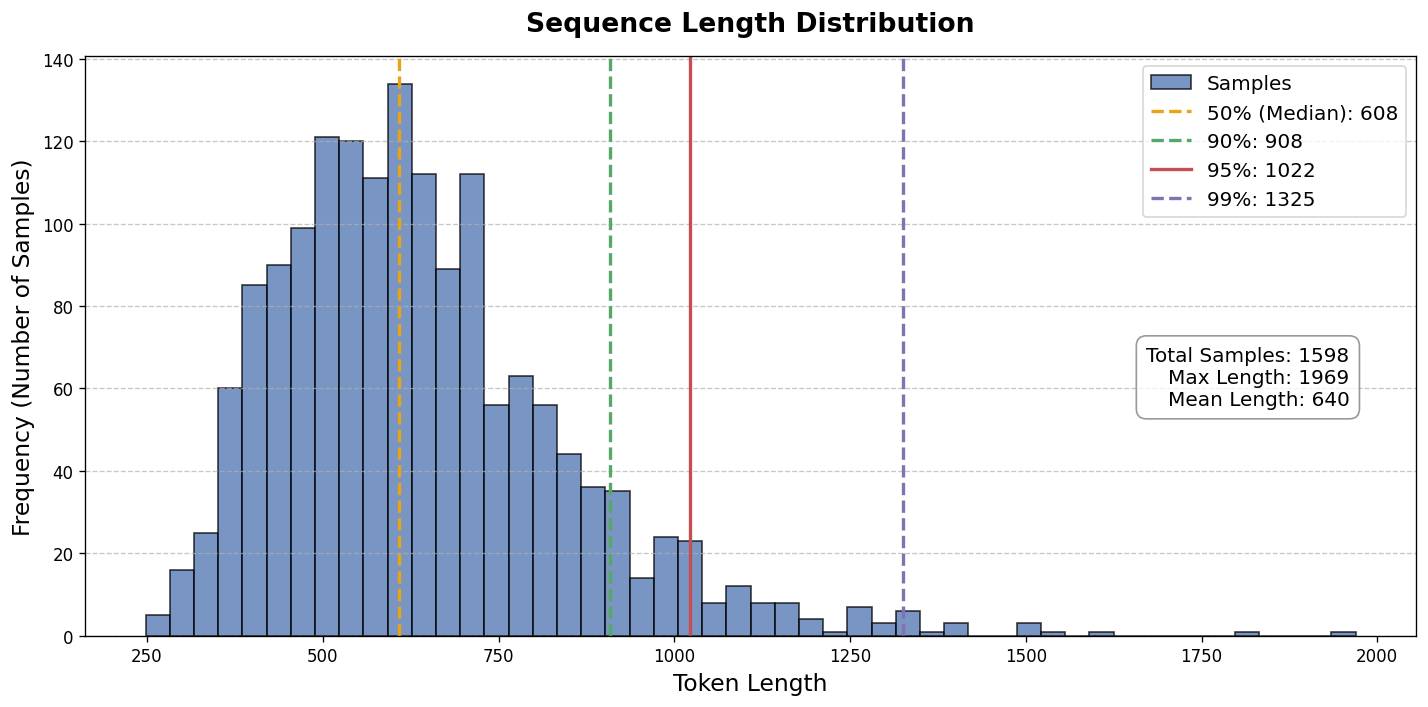

📊 分布图已保存至: seq_len_distribution.png


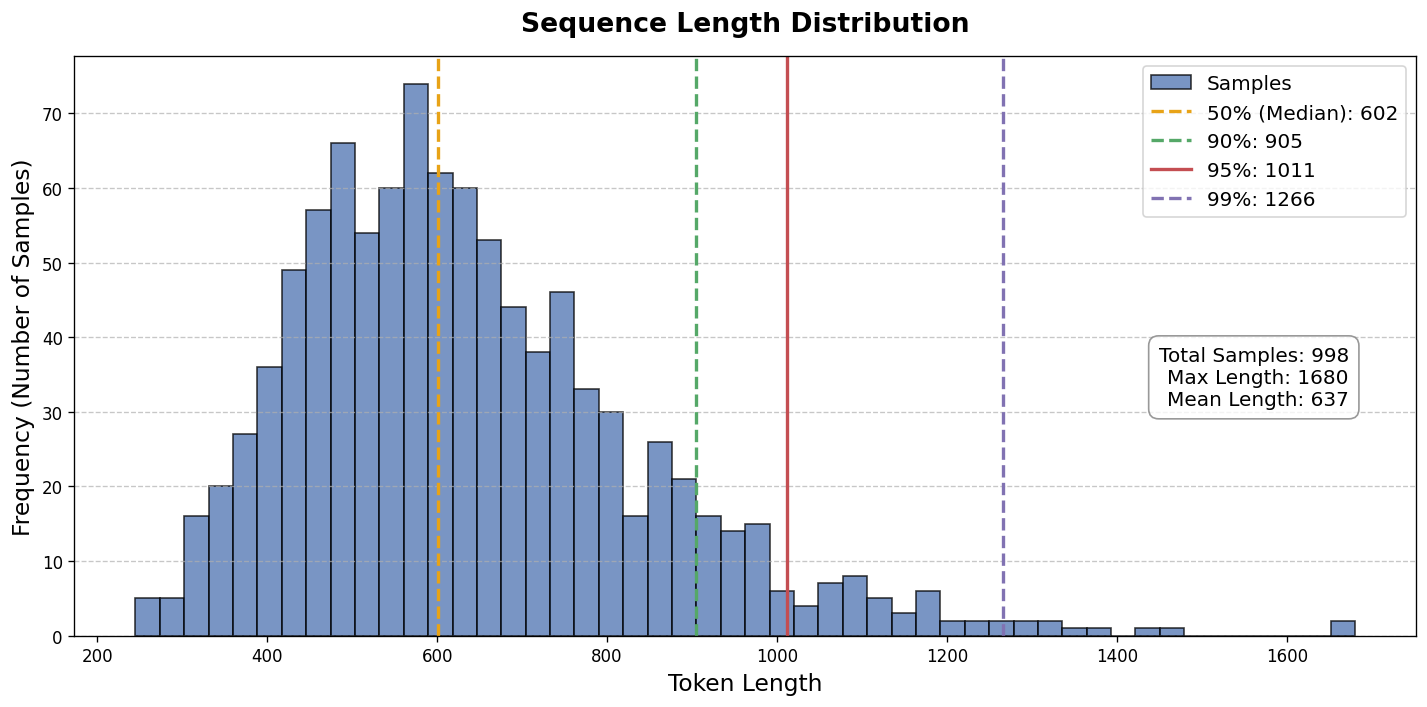

In [5]:
import matplotlib.pyplot as plt
def plot_seq_len_distribution(seq_lengths, save_path="seq_len_distribution.png"):
    """
    绘制 Token 长度分布直方图，并在图中标注关键分位数。

    参数:
        seq_lengths (list 或 np.ndarray): 包含所有样本 Token 长度的列表或数组。
        save_path (str): 图片保存路径。如果为 None，则只显示不保存。
    """

    # 确保是 numpy 数组以便计算
    lengths_array = np.array(seq_lengths)

    # 计算关键统计量
    p50 = np.percentile(lengths_array, 50)
    p90 = np.percentile(lengths_array, 90)
    p95 = np.percentile(lengths_array, 95)
    p99 = np.percentile(lengths_array, 99)
    mean_len = np.mean(lengths_array)
    max_len = np.max(lengths_array)

    # 创建画布
    plt.figure(figsize=(12, 6), dpi=120)

    # 绘制直方图
    # bins=50 表示将数据分成 50 个柱子，可根据数据量自行调整
    n, bins, patches = plt.hist(
        lengths_array,
        bins=50,
        color='#4C72B0',
        edgecolor='black',
        alpha=0.75,
        label='Samples'
    )

    # 获取最高柱子的高度，用于确定参考线标注文本的 y 轴高度
    max_y = n.max()

    # 绘制关键分位数垂直参考线
    plt.axvline(p50, color='#E8A317', linestyle='--', linewidth=2, label=f'50% (Median): {p50:.0f}')
    plt.axvline(p90, color='#55A868', linestyle='--', linewidth=2, label=f'90%: {p90:.0f}')
    plt.axvline(p95, color='#C44E52', linestyle='-', linewidth=2, label=f'95%: {p95:.0f}')
    plt.axvline(p99, color='#8172B2', linestyle='--', linewidth=2, label=f'99%: {p99:.0f}')

    # 设置图表标题和坐标轴标签
    plt.title('Sequence Length Distribution', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Token Length', fontsize=14)
    plt.ylabel('Frequency (Number of Samples)', fontsize=14)

    # 在右上角添加文本框显示极限值
    info_text = f"Total Samples: {len(lengths_array)}\nMax Length: {max_len:.0f}\nMean Length: {mean_len:.0f}"
    plt.text(0.95, 0.5, info_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    # 优化网格和图例
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    # 保存与显示
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"📊 分布图已保存至: {save_path}")

    plt.show()

plot_seq_len_distribution(train_seq_len_list)
plot_seq_len_distribution(val_seq_len_list)

In [32]:
from transformers import AutoTokenizer

messages = [
    {"role": "user", "content": '这是一个问题'},
    {"role": "assistant", "content": '这是一个答案'}
]

# 假设已经加载了分词器 (注意 Qwen 系列通常需要设置 trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained('/home/lyq/Models/Qwen3.5-4B', trust_remote_code=True)

# 确保 pad_token 存在
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# 1. 获取 User Prompt 的真实长度
# 修复：添加 return_dict=True 才能像字典一样提取 'input_ids'
user_prompt_dict = tokenizer.apply_chat_template(
    [messages[0]],
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True
)
user_prompt_len = len(user_prompt_dict['input_ids'])

# 2. 获取包含 Padding 和 Truncation 的完整序列
result = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=False,
    tokenize=True,
    max_length=20,
    padding='max_length',
    truncation=True,
    return_dict=True  # 修复：添加 return_dict=True
)

input_ids = result['input_ids']
attn_mask = result['attention_mask']

# 3. 计算长度 (加入截断保护机制)
# 实际的有效 token 数量 (不含 padding)
actual_valid_tokens = sum(attn_mask)

# 安全校验：如果截断过于严重，导致连 user_prompt 都被截断了
if actual_valid_tokens <= user_prompt_len:
    # 说明剩下的全是不完整的 prompt，没有任何 answer
    # 这种情况下整条数据都不该计算 loss
    label = [-100] * len(input_ids)
else:
    # 正常情况计算
    nums_answer_token = actual_valid_tokens - user_prompt_len
    nums_padding_token = len(input_ids) - actual_valid_tokens

    label = (
        [-100] * user_prompt_len +                                        # Prompt 设为 -100
        input_ids[user_prompt_len : user_prompt_len + nums_answer_token] + # Answer 保持原 ID
        [-100] * nums_padding_token                                       # Padding 设为 -100
    )

print("Input IDs:", input_ids)
print("Attention Mask:", attn_mask)
print("Labels:", label)

# 最终校验：保证维度完全对齐
assert len(input_ids) == len(attn_mask) == len(label), "维度对齐失败！"

Input IDs: [248045, 846, 198, 109455, 96304, 248046, 198, 248045, 74455, 198, 248068, 271, 248069, 271, 109455, 97632, 248046, 198, 248044, 248044]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Labels: [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 248069, 271, 109455, 97632, 248046, 198, -100, -100]


In [33]:
def decode_labels_for_visualization(tokenizer, input_ids, labels):
    """
    可视化对比 input_ids 和 labels，还原 -100 掩盖的原始内容。
    """
    print("\n" + "="*60)
    print("🧠 Label 与 Token 映射可视化分析")
    print("="*60)

    # 用于存储连续的片段
    segments = []
    current_type = None  # 'MASKED' 或 'VALID'
    current_tokens = []
    current_original_ids = []

    # 1. 将 token 按照 -100 和正常 ID 进行分段
    for idx, (label_id, input_id) in enumerate(zip(labels, input_ids)):
        token_type = "MASKED" if label_id == -100 else "VALID"

        # 如果类型发生切换，保存上一个片段并开启新片段
        if current_type != token_type:
            if current_type is not None:
                segments.append({
                    "type": current_type,
                    "tokens": current_tokens,
                    "original_ids": current_original_ids
                })
            current_type = token_type
            current_tokens = []
            current_original_ids = []

        current_tokens.append(label_id)
        current_original_ids.append(input_id)

    # 保存最后一个片段
    if current_tokens:
        segments.append({
            "type": current_type,
            "tokens": current_tokens,
            "original_ids": current_original_ids
        })

    # 2. 逐段打印和 Decode
    for i, seg in enumerate(segments):
        length = len(seg["tokens"])

        if seg["type"] == "MASKED":
            # 对于 -100 的部分，我们拿它对应的 input_ids 去 decode，看看它原本是什么
            original_text = tokenizer.decode(seg["original_ids"])
            print(f"[{i+1}] ❌ 忽略区域 (Label = -100) | Token 数量: {length}")

            # 判断这是头部的 Prompt 还是尾部的 Padding
            if seg["original_ids"][0] == tokenizer.pad_token_id:
                print(f"    ➡️ 判定为: 【尾部 Padding 填充】")
            else:
                print(f"    ➡️ 判定为: 【User Prompt (不计算 Loss)】")
                # 使用 repr() 打印，可以清晰地看到 \n 等特殊字符
                print(f"    👀 掩盖的原始文本: {repr(original_text)}")

        else:
            # 对于有效的 label，直接 decode
            valid_text = tokenizer.decode(seg["tokens"])
            print(f"[{i+1}] ✅ 核心区域 (计算 Loss) | Token 数量: {length}")
            print(f"    ➡️ 判定为: 【Assistant 回答 (模型学习的目标)】")
            print(f"    👀 保留的文本词: {repr(valid_text)}")
            # 如果 token 数量不是特别多，打印出具体的 Token IDs 供核对
            if length < 50:
                print(f"    🔢 对应的 Token IDs: {seg['tokens']}")
            else:
                print(f"    🔢 对应的 Token IDs: {seg['tokens'][:10]} ... (省略中间) ... {seg['tokens'][-5:]}")

        print("-" * 60)

# ==========================================
# 调用示例 (接你之前的代码)：
# ==========================================
# 假设前文已经得到了正确的 input_ids 和 label
decode_labels_for_visualization(tokenizer, input_ids, label)


🧠 Label 与 Token 映射可视化分析
[1] ❌ 忽略区域 (Label = -100) | Token 数量: 12
    ➡️ 判定为: 【User Prompt (不计算 Loss)】
    👀 掩盖的原始文本: '<|im_start|>user\n这是一个问题<|im_end|>\n<|im_start|>assistant\n<think>\n\n'
------------------------------------------------------------
[2] ✅ 核心区域 (计算 Loss) | Token 数量: 6
    ➡️ 判定为: 【Assistant 回答 (模型学习的目标)】
    👀 保留的文本词: '</think>\n\n这是一个答案<|im_end|>\n'
    🔢 对应的 Token IDs: [248069, 271, 109455, 97632, 248046, 198]
------------------------------------------------------------
[3] ❌ 忽略区域 (Label = -100) | Token 数量: 2
    ➡️ 判定为: 【尾部 Padding 填充】
------------------------------------------------------------


In [5]:
from transformers import AutoTokenizer
import json

with open('/home/lyq/projects/FactVerf/dataset/FEVER/train_claim.jsonl', 'r', encoding='utf-8') as f:
    train_claims_content = [json.loads(line)['text'] for line in f.readlines()]

with open('/home/lyq/projects/FactVerf/dataset/FEVER/train_evidence.jsonl', 'r', encoding='utf-8') as f:
    train_evidences_content = [json.loads(line)['text'] for line in f.readlines()]

print("Loading tokenizer microsoft/deberta-v3-base...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

# 使用批量编码，并直接指定 return_length=True 自动计算长度，速度比 for 循环快得多
print("Calculating claim sequence lengths...")
claims_encodings = tokenizer(train_claims_content, add_special_tokens=True, return_length=True)
train_claims_seq_len = claims_encodings['length']

print("Calculating evidence sequence lengths...")
evidences_encodings = tokenizer(train_evidences_content, add_special_tokens=True, return_length=True)
train_evidences_seq_len = evidences_encodings['length']

# 绘制直方图进行可视化分析
plot_seq_len_distribution(train_claims_seq_len, save_path="train_claims_seq_len.png")
plot_seq_len_distribution(train_evidences_seq_len, save_path="train_evidences_seq_len.png")




Loading tokenizer microsoft/deberta-v3-base...


[transformers] Could not extract SentencePiece model from /home/lyq/.cache/huggingface/hub/models--microsoft--deberta-v3-base/snapshots/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/spm.model using sentencepiece library due to 
SentencePieceExtractor requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.
. Falling back to TikToken extractor.


ValueError: Error parsing line b'\x0e' in /home/lyq/.cache/huggingface/hub/models--microsoft--deberta-v3-base/snapshots/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/spm.model